# Study Gradient Flow & Vanishing Gradient Problem

**We will do 3 things:**

- Plot derivative (gradient) of each activation

- Simulate vanishing gradient (Sigmoid/Tanh)

- Simulate dead ReLU & exploding gradient

# Plot Gradients of Activation Functions

**Import Library**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Input range
x = np.linspace(-10, 10, 400)

**ACTIVATIONS FUNCTION**

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_grad(x):
    return 1 - np.tanh(x)**2

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def leaky_relu(x):
    return np.where(x > 0, x, 0.01*x)

def leaky_relu_grad(x):
    return np.where(x > 0, 1, 0.01)

**PLOT**

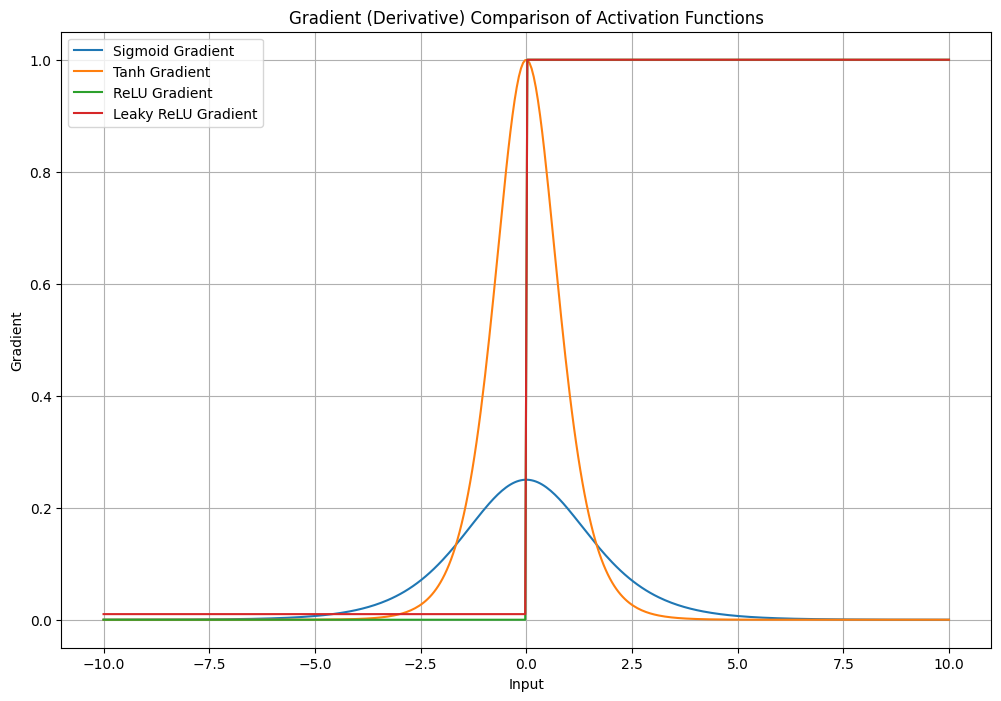

In [4]:
plt.figure(figsize=(12,8))

plt.plot(x, sigmoid_grad(x), label="Sigmoid Gradient")
plt.plot(x, tanh_grad(x), label="Tanh Gradient")
plt.plot(x, relu_grad(x), label="ReLU Gradient")
plt.plot(x, leaky_relu_grad(x), label="Leaky ReLU Gradient")

plt.title("Gradient (Derivative) Comparison of Activation Functions")
plt.xlabel("Input")
plt.ylabel("Gradient")
plt.legend()
plt.grid()
plt.show()

**What You Will Observe**

Sigmoid: gradient → almost 0 at large + or −

network stops learning

- Tanh: better but still fades

- ReLU: strong gradient for positive values

- Leaky ReLU: always non-zero → best gradient flow

- This is the vanishing gradient problem.

# Simulating Vanishing Gradient Across Layers

We simulate a deep network (like 20 layers).

**Mathematically**:

Backpropagation multiplies gradients repeatedly.

If gradient < 1 → becomes almost zero.

**Vanishing Gradient Simulation**

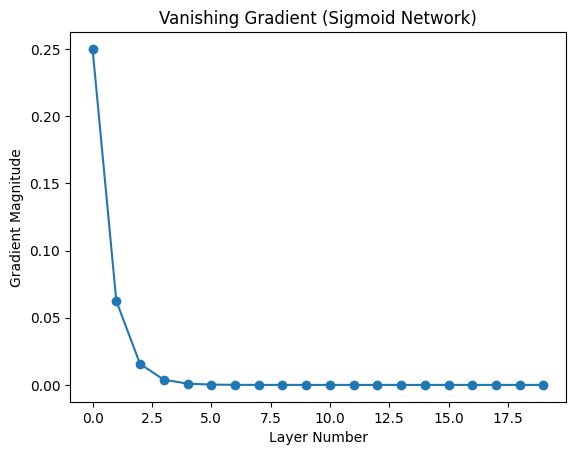

In [6]:
layers = 20
gradient = 1.0
gradients = []

# simulate sigmoid derivative ~ 0.25
for i in range(layers):
    gradient *= 0.25
    gradients.append(gradient)

plt.plot(range(layers), gradients, marker='o')
plt.title("Vanishing Gradient (Sigmoid Network)")
plt.xlabel("Layer Number")
plt.ylabel("Gradient Magnitude")
plt.show()

Earlier layers never learn.

This is exactly why early deep networks (before 2012) failed.

# Dead ReLU Problem

**ReLU gradient:**


> x < 0 → gradient = 0

Neuron becomes permanently inactive.

**Dead ReLU Visualization**

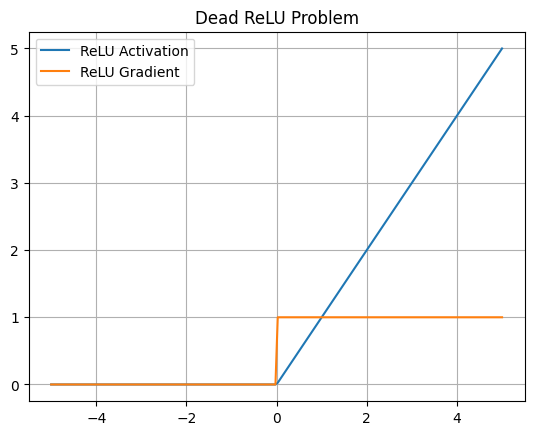

In [8]:
x = np.linspace(-5, 5, 200)

plt.plot(x, relu(x), label="ReLU Activation")
plt.plot(x, relu_grad(x), label="ReLU Gradient")

plt.title("Dead ReLU Problem")
plt.legend()
plt.grid()
plt.show()

Left side → gradient = 0

> Neuron never updates again

That is dead neuron

# Exploding Gradient

Opposite of vanishing gradient.

If gradient > 1 repeatedly:

> 1.5 × 1.5 × 1.5 × 1.5 × ... → HUGE


Weights become NaN

# Exploding Gradient

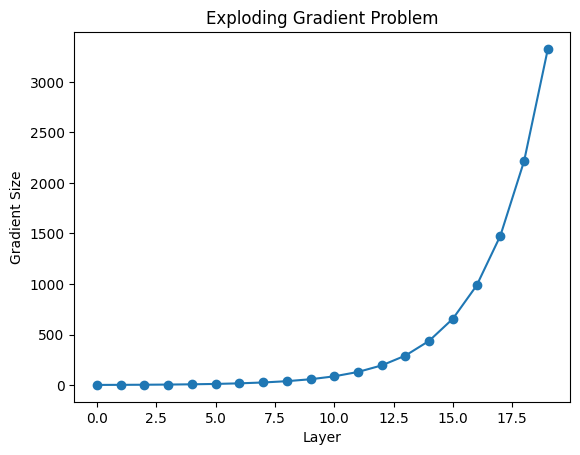

In [9]:
layers = 20
gradient = 1.5
gradients = []

value = 1
for i in range(layers):
    value *= gradient
    gradients.append(value)

plt.plot(range(layers), gradients, marker='o')
plt.title("Exploding Gradient Problem")
plt.xlabel("Layer")
plt.ylabel("Gradient Size")
plt.show()


**Why This Happens (Real Neural Network)**

During backpropagation:

If weights > 1

- → gradient keeps multiplying
- → becomes enormous

This is exactly what your curve shows

**What Happens to the Model**

When gradients explode:

- Weights become extremely large
- Loss becomes NaN
- Training suddenly crashes
- Accuracy becomes 10% forever

That is exploding gradient

| Problem            | Caused By               |
| ------------------ | ----------------------- |
| Vanishing gradient | Sigmoid/Tanh saturation |
| Dead neuron        | ReLU negative region    |
| Exploding gradient | Large weight updates    |
